### Import Liberies

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

#### Load dataset

In [4]:
df = pd.read_csv('Dataset\student_habits_performance.csv')

#### Top 5 records

In [5]:
df.head()

,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,S1000,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes,56.2
1,S1001,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No,100.0
2,S1002,21,Male,1.4,3.1,1.3,No,94.8,8.0,Poor,1,High School,Poor,1,No,34.3
3,S1003,23,Female,1.0,3.9,1.0,No,71.0,9.2,Poor,4,Master,Good,1,Yes,26.8
4,S1004,19,Female,5.0,4.4,0.5,No,90.9,4.9,Fair,3,Master,Good,1,No,66.4


#### Shape of dataset

In [6]:
print(f'Number of rows: {df.shape[0]}')
print(f'Number of columns: {df.shape[1]}')

Number of rows: 1000
Number of columns: 16


#### Dataset info

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   student_id                     1000 non-null   object 
 1   age                            1000 non-null   int64  
 2   gender                         1000 non-null   object 
 3   study_hours_per_day            1000 non-null   float64
 4   social_media_hours             1000 non-null   float64
 5   netflix_hours                  1000 non-null   float64
 6   part_time_job                  1000 non-null   object 
 7   attendance_percentage          1000 non-null   float64
 8   sleep_hours                    1000 non-null   float64
 9   diet_quality                   1000 non-null   object 
 10  exercise_frequency             1000 non-null   int64  
 11  parental_education_level       909 non-null    object 
 12  internet_quality               1000 non-null   ob

### Feature Seclection

In [8]:
features = ['student_id', 'age', 'extracurricular_participation', 'gender']
df = df.drop(columns=features, axis=1)
print(f"Features used for model: \n{df.columns.to_list()}")

Features used for model: 
['study_hours_per_day', 'social_media_hours', 'netflix_hours', 'part_time_job', 'attendance_percentage', 'sleep_hours', 'diet_quality', 'exercise_frequency', 'parental_education_level', 'internet_quality', 'mental_health_rating', 'exam_score']


In [9]:
df.head()

,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,exam_score
0,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,56.2
1,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,100.0
2,1.4,3.1,1.3,No,94.8,8.0,Poor,1,High School,Poor,1,34.3
3,1.0,3.9,1.0,No,71.0,9.2,Poor,4,Master,Good,1,26.8
4,5.0,4.4,0.5,No,90.9,4.9,Fair,3,Master,Good,1,66.4


#### Select Input Features and Target

In [10]:
X = df.drop('exam_score', axis=1)
y = df['exam_score']

In [11]:
numerical_features = X.select_dtypes(exclude="object").columns
categorical_features = X.select_dtypes(include="object").columns
print(numerical_features)
print(categorical_features)

Index(['study_hours_per_day', 'social_media_hours', 'netflix_hours',
       'attendance_percentage', 'sleep_hours', 'exercise_frequency',
       'mental_health_rating'],
      dtype='object')
Index(['part_time_job', 'diet_quality', 'parental_education_level',
       'internet_quality'],
      dtype='object')


In [12]:
X[numerical_features].head()

,study_hours_per_day,social_media_hours,netflix_hours,attendance_percentage,sleep_hours,exercise_frequency,mental_health_rating
0,0.0,1.2,1.1,85.0,8.0,6,8
1,6.9,2.8,2.3,97.3,4.6,6,8
2,1.4,3.1,1.3,94.8,8.0,1,1
3,1.0,3.9,1.0,71.0,9.2,4,1
4,5.0,4.4,0.5,90.9,4.9,3,1


In [13]:
X[categorical_features].head()

,part_time_job,diet_quality,parental_education_level,internet_quality
0,No,Fair,Master,Average
1,No,Good,High School,Average
2,No,Poor,High School,Poor
3,No,Poor,Master,Good
4,No,Fair,Master,Good


In [18]:
nominal_feature = ['part_time_job']
ordinal_feature = ['diet_quality', 'parental_education_level', 'internet_quality']

#### Split dataset for train and test

In [15]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.2, random_state=0)

In [16]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

X_train: (800, 11)
X_test : (200, 11)


In [17]:
X_train.head()

,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating
687,2.2,1.5,1.3,Yes,89.8,6.5,Poor,5,Master,Average,9
500,5.5,1.1,1.4,No,84.4,4.9,Fair,0,Bachelor,Good,6
332,2.7,1.9,2.3,No,71.6,7.7,Fair,3,High School,Poor,8
979,1.3,2.2,1.8,No,76.1,5.0,Good,6,High School,Poor,10
817,4.9,1.5,3.4,No,71.4,6.9,Good,6,High School,Good,7


## Create Pipepline

#### Numerical preprocessing

In [ ]:
numeric_pipeline = Pipeline(
    steps=[
        ("impute_mean", SimpleImputer(strategy="mean")),
        ("scaler", StandardScaler())
    ]
)

#### Nominal preprocessing

In [ ]:
nominal_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("ohe", OneHotEncoder(
            drop='first',
            handle_unknown="ignore",
            sparse_output=False
        ))
    ]
)

#### Ordinal preprocessing

In [21]:
ordinal_encoder = OrdinalEncoder(
    categories=[
        ["Poor", "Fair", "Good"],
        ["High School", "Bachelor", "Master"],
        ["Poor", "Average", "Good"]
    ]
)

In [22]:
ordinal_pipeline = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('ord_encoder', ordinal_encoder)
    ]
)

#### Column Transformer

In [24]:
preprocessor = ColumnTransformer(
    [
        ('numerical', numeric_pipeline, numerical_features),
        ('nominal', nominal_pipeline, nominal_feature),
        ('ordinal', ordinal_pipeline, ordinal_feature)
    ]
)

#### Add Linear Regression

In [25]:
model_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

## Train

In [26]:
model_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numerical',
                                                  Pipeline(steps=[('impute_mean',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['study_hours_per_day', 'social_media_hours', 'netflix_hours',
       'attendance_percentage', 'sleep_hours', 'exercise_frequency',
       'mental_health_rating'],
      dtype='object')),
                                                 ('nominal',
                                                  Pipeline(steps=[('...
                                                                                 sparse_output=False))]),
                                                  ['part_time_job']),
                                                 ('ordinal',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ord_encoder',
                                                                   OrdinalEncoder(categories=[['Poor',
                                                                                               'Fair',
                                                                                               'Good'],
                                                                                              ['High '
                                                                                               'School',
                                                                                               'Bachelor',
                                                                                               'Master'],
                                                                                              ['Poor',
                                                                                               'Average',
                                                                                               'Good']]))]),
                                                  ['diet_quality',
                                                   'parental_education_level',
                                                   'internet_quality'])])),
                ('model', LinearRegression())])

#### Prediction

In [30]:
y_train_pred = model_pipeline.predict(X_train)
y_test_pred = model_pipeline.predict(X_test)

In [41]:
y_test[:5]

993    70.9
859    36.8
298    91.3
553    88.0
672    69.4
Name: exam_score, dtype: float64

In [42]:
y_test_pred[:5]

array([72.59260517, 40.72095981, 83.15905635, 87.10736557, 68.14020425])

In [31]:
model = model_pipeline['model']

print(f'Coefficient: {model.coef_}')
print(f'Intercept: {model.intercept_}')

Coefficient: [13.91843329 -3.12891432 -2.43233762  1.47890024  2.59586373  2.93235874
  5.61139178  0.19171097 -0.16459802  0.05367375 -0.43610704]
Intercept: 70.20087000083659


#### Model evolution

In [ ]:
mae = mean_absolute_error(y_test, y_test_pred)
mse = mean_squared_error(y_test, y_test_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_test_pred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R²  :", r2)

MAE : 4.114808245596767
MSE : 25.607543942580406
RMSE: 5.060389702639552
R²  : 0.9124870086872735


#### Plot actual vs Predicted values

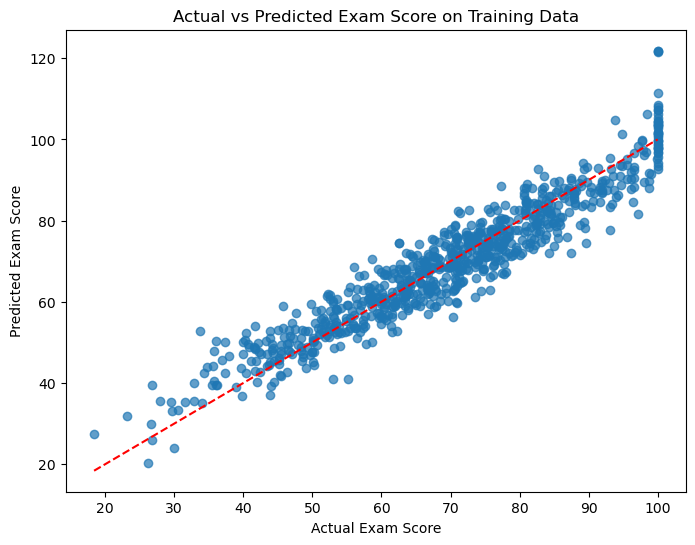

In [33]:
plt.figure(figsize=(8, 6))

plt.scatter(y_train, y_train_pred, alpha=0.7)
plt.plot(
    [y_train.min(), y_train.max()],
    [y_train.min(), y_train.max()],
    linestyle="--", color='red'
)

plt.xlabel("Actual Exam Score")
plt.ylabel("Predicted Exam Score")
plt.title("Actual vs Predicted Exam Score on Training Data")

plt.show()

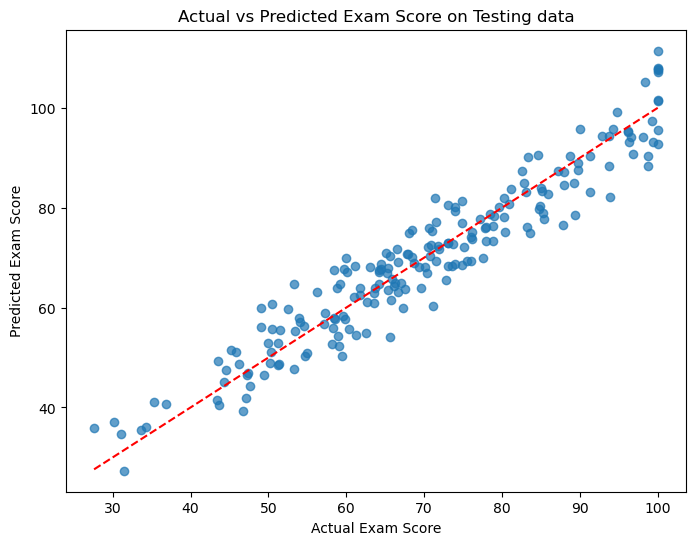

In [34]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_test_pred, alpha=0.7)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--", color='red'
)

plt.xlabel("Actual Exam Score")
plt.ylabel("Predicted Exam Score")
plt.title("Actual vs Predicted Exam Score on Testing data")
plt.show()

## Save the complete Pipeline

In [35]:
import pickle

pickle.dump(model_pipeline, open('Models/student_performance_linear_regression.pkl', 'wb'))